5.1(o)
1. validation and Training
2. randomly partition the data into another file

5.2(p)
1.Pre-processing


In [1]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import numpy as np

from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

test_year = pd.read_csv('test_years.csv')
# print(test_year)

data = pd.read_csv('Nino3.4_data.csv')
print("Length of data:", data.shape)
testSet = data[data["year"].isin(test_year["year"])]
print("Length of testSet:", testSet.shape)

remaining = data[~data["year"].isin(test_year["year"])]
print("Length of remaining:", remaining.shape)

# Partition (Split Ratio -> Training and Validation)
trainingSet,validationSet = train_test_split(remaining, test_size=0.33, random_state=69, shuffle=True)

# extract the data from the file 
# normalise the data
# save the data to joblib 
scaler = MinMaxScaler()
input = ["nino_tminus2", "nino_tminus1", "nino_t"]
trainingSet[input] = scaler.fit_transform(trainingSet[input])
validationSet[input] = scaler.transform(validationSet[input])

testSet.to_csv('testSetB.csv', index=False) # values are unscaled
trainingSet.to_csv('trainingSetB.csv', index = False)
validationSet.to_csv('validationSetB.csv', index = False)

print("Lenght of trainingSet:", trainingSet.shape)
print("Length of validationSet:", validationSet.shape)
joblib.dump(scaler, 'input_scalerB.pkl')

Length of data: (802, 11)
Length of testSet: (72, 11)
Length of remaining: (730, 11)
Lenght of trainingSet: (489, 11)
Length of validationSet: (241, 11)


['input_scalerB.pkl']

5.2(q)
1. build a model to predict the 6 output at one go

Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8264 - val_loss: 0.7430
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7706 - val_loss: 0.6956
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7179 - val_loss: 0.6269
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6330 - val_loss: 0.5173
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5225 - val_loss: 0.4132
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4393 - val_loss: 0.3559
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3965 - val_loss: 0.3287
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3761 - val_loss: 0.3156
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3660 - val_loss: 0.3089
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3604 - val_loss: 0.3051
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3570 - val_loss: 0.3027
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.35

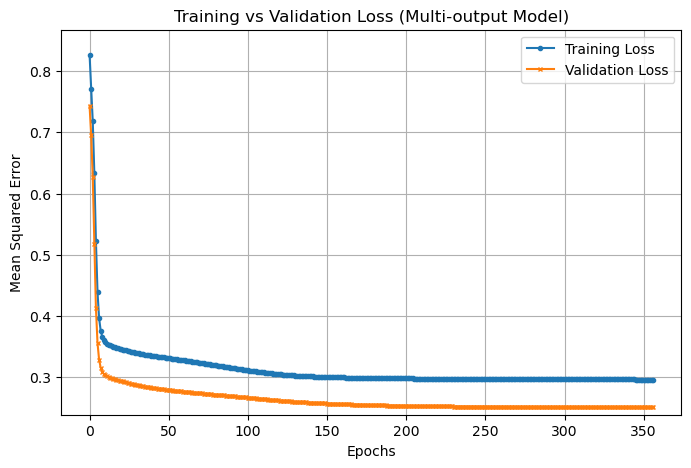

Validation loss at last epoch: 0.25112807750701904


In [10]:
np.random.seed(69)
tf.random.set_seed(69)

target = ["nino_tplus1", "nino_tplus2",  "nino_tplus3", "nino_tplus4", "nino_tplus5", "nino_tplus6"]
X_train = trainingSet[input]
y_train = trainingSet[target]


X_val = validationSet[input]
y_val = validationSet[target]

MOmodel = Sequential([
    Dense(16, activation='tanh', input_shape=(3,)),
    Dense(8, activation='tanh'),
    Dense(8, activation='tanh'),
    Dense(6)
])

MOmodel.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate=0.001)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = MOmodel.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

print(MOmodel(X_val))

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o', markersize=3)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x', markersize=3)
plt.title('Training vs Validation Loss (Multi-output Model)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)

# Optionally zoom the y-axis to see fluctuations better
all_loss = history.history['loss'] + history.history['val_loss']
plt.ylim([min(all_loss)*0.95, max(all_loss)*1.05])

plt.show()

val_losses = history.history['val_loss']
train_losses = history.history['loss']
print("Validation loss at last epoch:", val_losses[-1])

MOmodel.save('MOmodel.keras')

5.2(s)
1. Using testSet Data
2. calculate the RMSE and COEFF

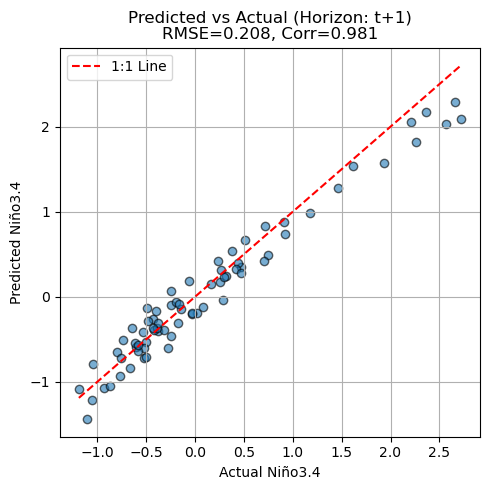

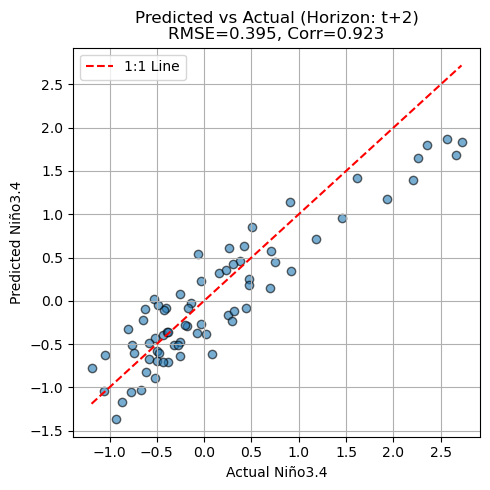

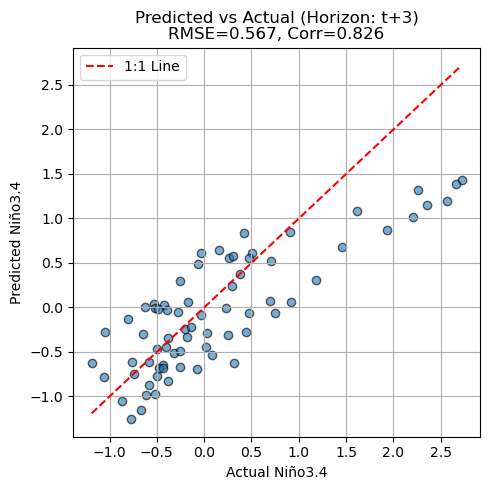

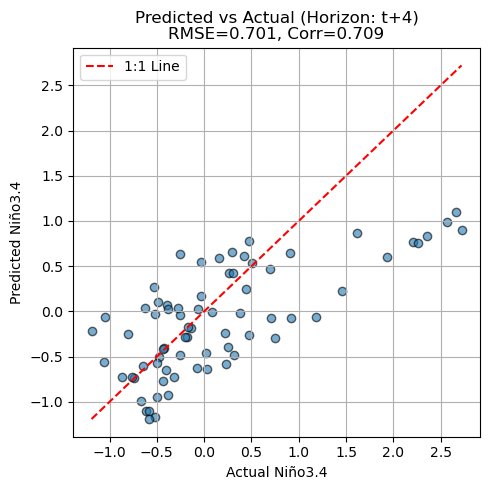

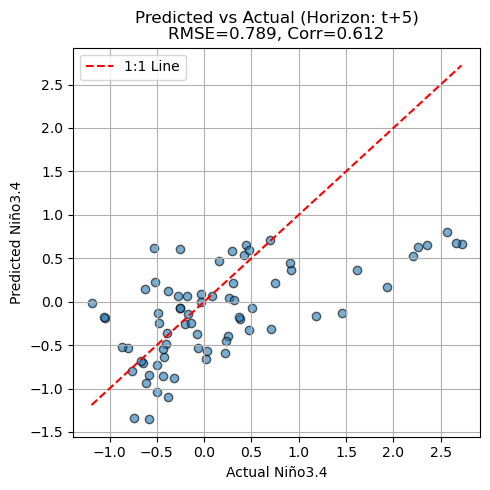

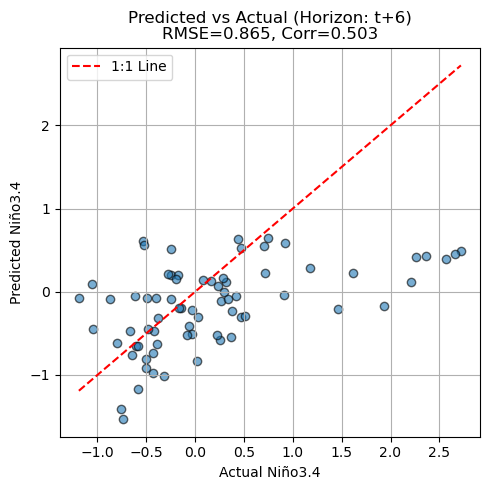

✅ Results saved to TaskB_Evaluation.csv
  Horizon      RMSE  Pearson_corr
0     t+1  0.208302      0.980784
1     t+2  0.394947      0.922870
2     t+3  0.567479      0.826468
3     t+4  0.701265      0.709001
4     t+5  0.788833      0.612088
5     t+6  0.864855      0.503393


In [4]:
from sklearn.metrics import mean_squared_error
testData = pd.read_csv('testSet.csv')
X_test = testData[input]
scaler = joblib.load('input_scaler.pkl')
X_trans = scaler.transform(X_test)

model = tf.keras.models.load_model('MOmodel.keras')
prediction = model(X_trans)

actual = testData[target].values

rmse_list = []
pearson_list = []

for row in range(actual.transpose().shape[0]):
    actual_i = actual.transpose()[row]
    pred_i = prediction.numpy().transpose()[row]
    rmse = np.sqrt(mean_squared_error(actual_i, pred_i))
    coeff = np.corrcoef(pred_i, actual_i)[0,1]
    rmse_list.append(rmse)
    pearson_list.append(coeff)
    # print(f"t{row + 1}, RMSE: {rmse}, Coeff: {coeff}")
    plt.figure(figsize=(5, 5))
    plt.scatter(actual_i, pred_i, alpha=0.6, edgecolor='k')
    plt.plot([actual_i.min(), actual_i.max()],
             [actual_i.min(), actual_i.max()],
             'r--', label='1:1 Line')
    plt.title(f'Predicted vs Actual (Horizon: t+{row+1})\nRMSE={rmse:.3f}, Corr={coeff:.3f}')
    plt.xlabel('Actual Niño3.4')
    plt.ylabel('Predicted Niño3.4')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f'scatter_tplus{row+1}.png')  # saves plot for each horizon
    plt.show()

forecast_horizons = [f"t+{i+1}" for i in range(actual.shape[1])]

results_df = pd.DataFrame({
    "Horizon": forecast_horizons,
    "RMSE": rmse_list,
    "Pearson_corr": pearson_list
})

results_df.to_csv("TaskB_Evaluation.csv", index=False)

print("✅ Results saved to TaskB_Evaluation.csv")
print(results_df)

5.3(u)
Change the RMSE loss function, as the RMSE treat each of the output equally. 
Instead the t+1 will be more accurate while the accuracy decreases going to t+6.
Thus, we should have function to incrase the weight of the initial model and gradually decrase the weight of the next few training

Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7768 - val_loss: 0.7443
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6857 - val_loss: 0.6244
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5545 - val_loss: 0.4514
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4118 - val_loss: 0.3288
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3325 - val_loss: 0.2779
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2970 - val_loss: 0.2549
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2787 - val_loss: 0.2431
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2683 - val_loss: 0.2362
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2618 - val_loss: 0.2318
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2573 - val_loss: 0.2286
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2541 - val_loss: 0.2262
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.25

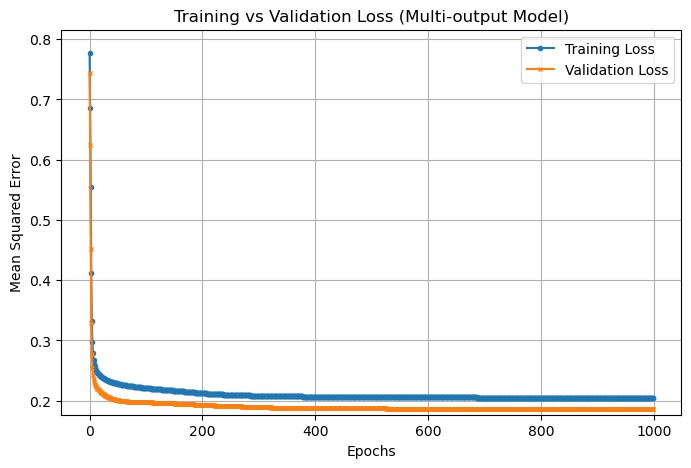

Validation loss at last epoch: 0.18612611293792725


In [5]:
weights = tf.constant([0.3, 0.25, 0.2, 0.15, 0.07, 0.03], dtype=tf.float32)

def weighted_mse(y_true, y_pred):
    squared_error = tf.square(y_true - y_pred)
    weighted_error = squared_error * weights
    return tf.reduce_mean(tf.reduce_sum(weighted_error, axis=1))

np.random.seed(69)
tf.random.set_seed(69)

target = ["nino_tplus1", "nino_tplus2",  "nino_tplus3", "nino_tplus4", "nino_tplus5", "nino_tplus6"]
X_train = trainingSet[input]
y_train = trainingSet[target]


X_val = validationSet[input]
y_val = validationSet[target]

weighted_MOmodel = Sequential([
    Dense(16, activation='tanh', input_shape=(3,)),
    Dense(8, activation='tanh'),
    Dense(8, activation='tanh'),
    Dense(6)
])

weighted_MOmodel.compile(
    loss=weighted_mse,
    optimizer=Adam(learning_rate=0.001)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = weighted_MOmodel.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

print(weighted_MOmodel(X_val))

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o', markersize=3)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x', markersize=3)
plt.title('Training vs Validation Loss (Multi-output Model)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)

# Optionally zoom the y-axis to see fluctuations better
all_loss = history.history['loss'] + history.history['val_loss']
plt.ylim([min(all_loss)*0.95, max(all_loss)*1.05])

plt.show()

val_losses = history.history['val_loss']
train_losses = history.history['loss']
print("Validation loss at last epoch:", val_losses[-1])

weighted_MOmodel.save('Weighted_MOmodel.keras')



Calculation of the Correlation of weightted

In [6]:
from sklearn.metrics import mean_squared_error
testData = pd.read_csv('testSet.csv')
X_test = testData[input]
scaler = joblib.load('input_scaler.pkl')
X_trans = scaler.transform(X_test)

weighted_model = tf.keras.models.load_model('Weighted_MOmodel.keras', custom_objects={'weighted_mse': weighted_mse})
prediction = weighted_model(X_trans)

actual = testData[target].values

rmse_list = []
pearson_list = []

for row in range(actual.transpose().shape[0]):
    actual_i = actual.transpose()[row]
    pred_i = prediction.numpy().transpose()[row]
    rmse = np.sqrt(mean_squared_error(actual_i, pred_i))
    coeff = np.corrcoef(pred_i, actual_i)[0,1]
    rmse_list.append(rmse)
    pearson_list.append(coeff)

forecast_horizons = [f"t+{i+1}" for i in range(actual.shape[1])]

results_df = pd.DataFrame({
    "Horizon": forecast_horizons,
    "RMSE": rmse_list,
    "Pearson_corr": pearson_list
})

results_df.to_csv("TaskB_Weighted_Evaluation.csv", index=False)

print("✅ Results saved to TaskB_Weighted_Evaluation.csv")
print(results_df)

✅ Results saved to TaskB_Weighted_Evaluation.csv
  Horizon      RMSE  Pearson_corr
0     t+1  0.204705      0.978794
1     t+2  0.391944      0.920842
2     t+3  0.554449      0.828443
3     t+4  0.696400      0.708115
4     t+5  0.791212      0.605206
5     t+6  0.851699      0.517676


In [8]:
# Load data
TaskA = pd.read_csv('TaskA_Evaluation.csv')
TaskB = pd.read_csv('TaskB_Evaluation.csv')
TaskBWeighted = pd.read_csv('TaskB_Weighted_Evaluation.csv')

# Optional: clean up inconsistent column names
TaskA.rename(columns={'Unnamed: 0': 'Horizon'}, inplace=True)

# Combine into one table
combined = pd.DataFrame({
    'Horizon': TaskA['Horizon'],
    'RMSE_TaskA': TaskA['RMSE'],
    'Corr_TaskA': TaskA['Pearson_corr'],
    'RMSE_TaskB': TaskB['RMSE'],
    'Corr_TaskB': TaskB['Pearson_corr'],
    'RMSE_TaskB_Weighted': TaskBWeighted['RMSE'],
    'Corr_TaskB_Weighted': TaskBWeighted['Pearson_corr']
})

# Display nicely
print(combined)

# Save to CSV
combined.to_csv("Combined_Evaluation_Table.csv", index=False)
print("✅ Combined table saved to Combined_Evaluation_Table.csv")


  Horizon  RMSE_TaskA  Corr_TaskA  RMSE_TaskB  Corr_TaskB  \
0     t+1    0.200787    0.980306    0.208302    0.980784   
1     t+2    0.361952    0.923212    0.394947    0.922870   
2     t+3    0.541417    0.820888    0.567479    0.826468   
3     t+4    0.748980    0.606687    0.701265    0.709001   
4     t+5    0.794479    0.611972    0.788833    0.612088   
5     t+6    0.867236    0.524573    0.864855    0.503393   

   RMSE_TaskB_Weighted  Corr_TaskB_Weighted  
0             0.204705             0.978794  
1             0.391944             0.920842  
2             0.554449             0.828443  
3             0.696400             0.708115  
4             0.791212             0.605206  
5             0.851699             0.517676  
✅ Combined table saved to Combined_Evaluation_Table.csv


6.1(x)
plot a graph of TaskA, TaskB, Weighted Task B RMSE

plot a graph of TaskA, TaskB, Weighted Task B Correlation

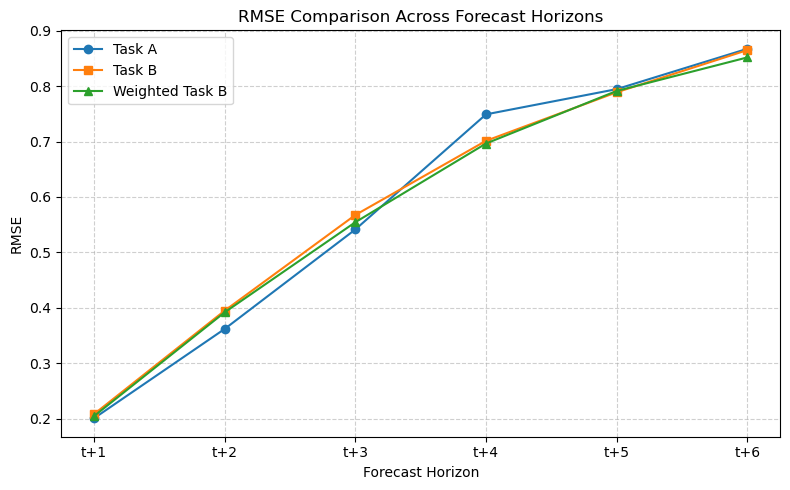

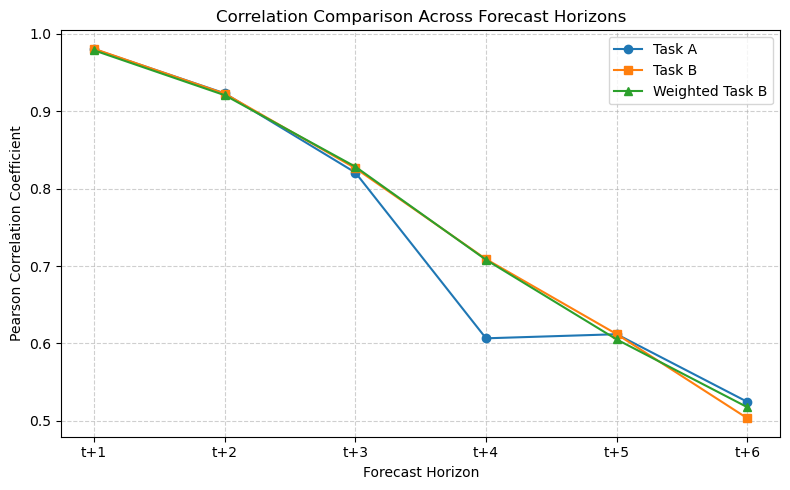

In [9]:
combined = pd.read_csv("Combined_Evaluation_Table.csv")

# --- Plot RMSE comparison ---
plt.figure(figsize=(8, 5))
plt.plot(combined["Horizon"], combined["RMSE_TaskA"], marker='o', label="Task A")
plt.plot(combined["Horizon"], combined["RMSE_TaskB"], marker='s', label="Task B")
plt.plot(combined["Horizon"], combined["RMSE_TaskB_Weighted"], marker='^', label="Weighted Task B")

plt.title("RMSE Comparison Across Forecast Horizons")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("RMSE_Comparison.png", dpi=300)
plt.show()

# --- Plot Correlation comparison ---
plt.figure(figsize=(8, 5))
plt.plot(combined["Horizon"], combined["Corr_TaskA"], marker='o', label="Task A")
plt.plot(combined["Horizon"], combined["Corr_TaskB"], marker='s', label="Task B")
plt.plot(combined["Horizon"], combined["Corr_TaskB_Weighted"], marker='^', label="Weighted Task B")

plt.title("Correlation Comparison Across Forecast Horizons")
plt.xlabel("Forecast Horizon")
plt.ylabel("Pearson Correlation Coefficient")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Correlation_Comparison.png", dpi=300)
plt.show()